In [1]:
import re
import torch
import torch.nn.functional as F
from collections import Counter

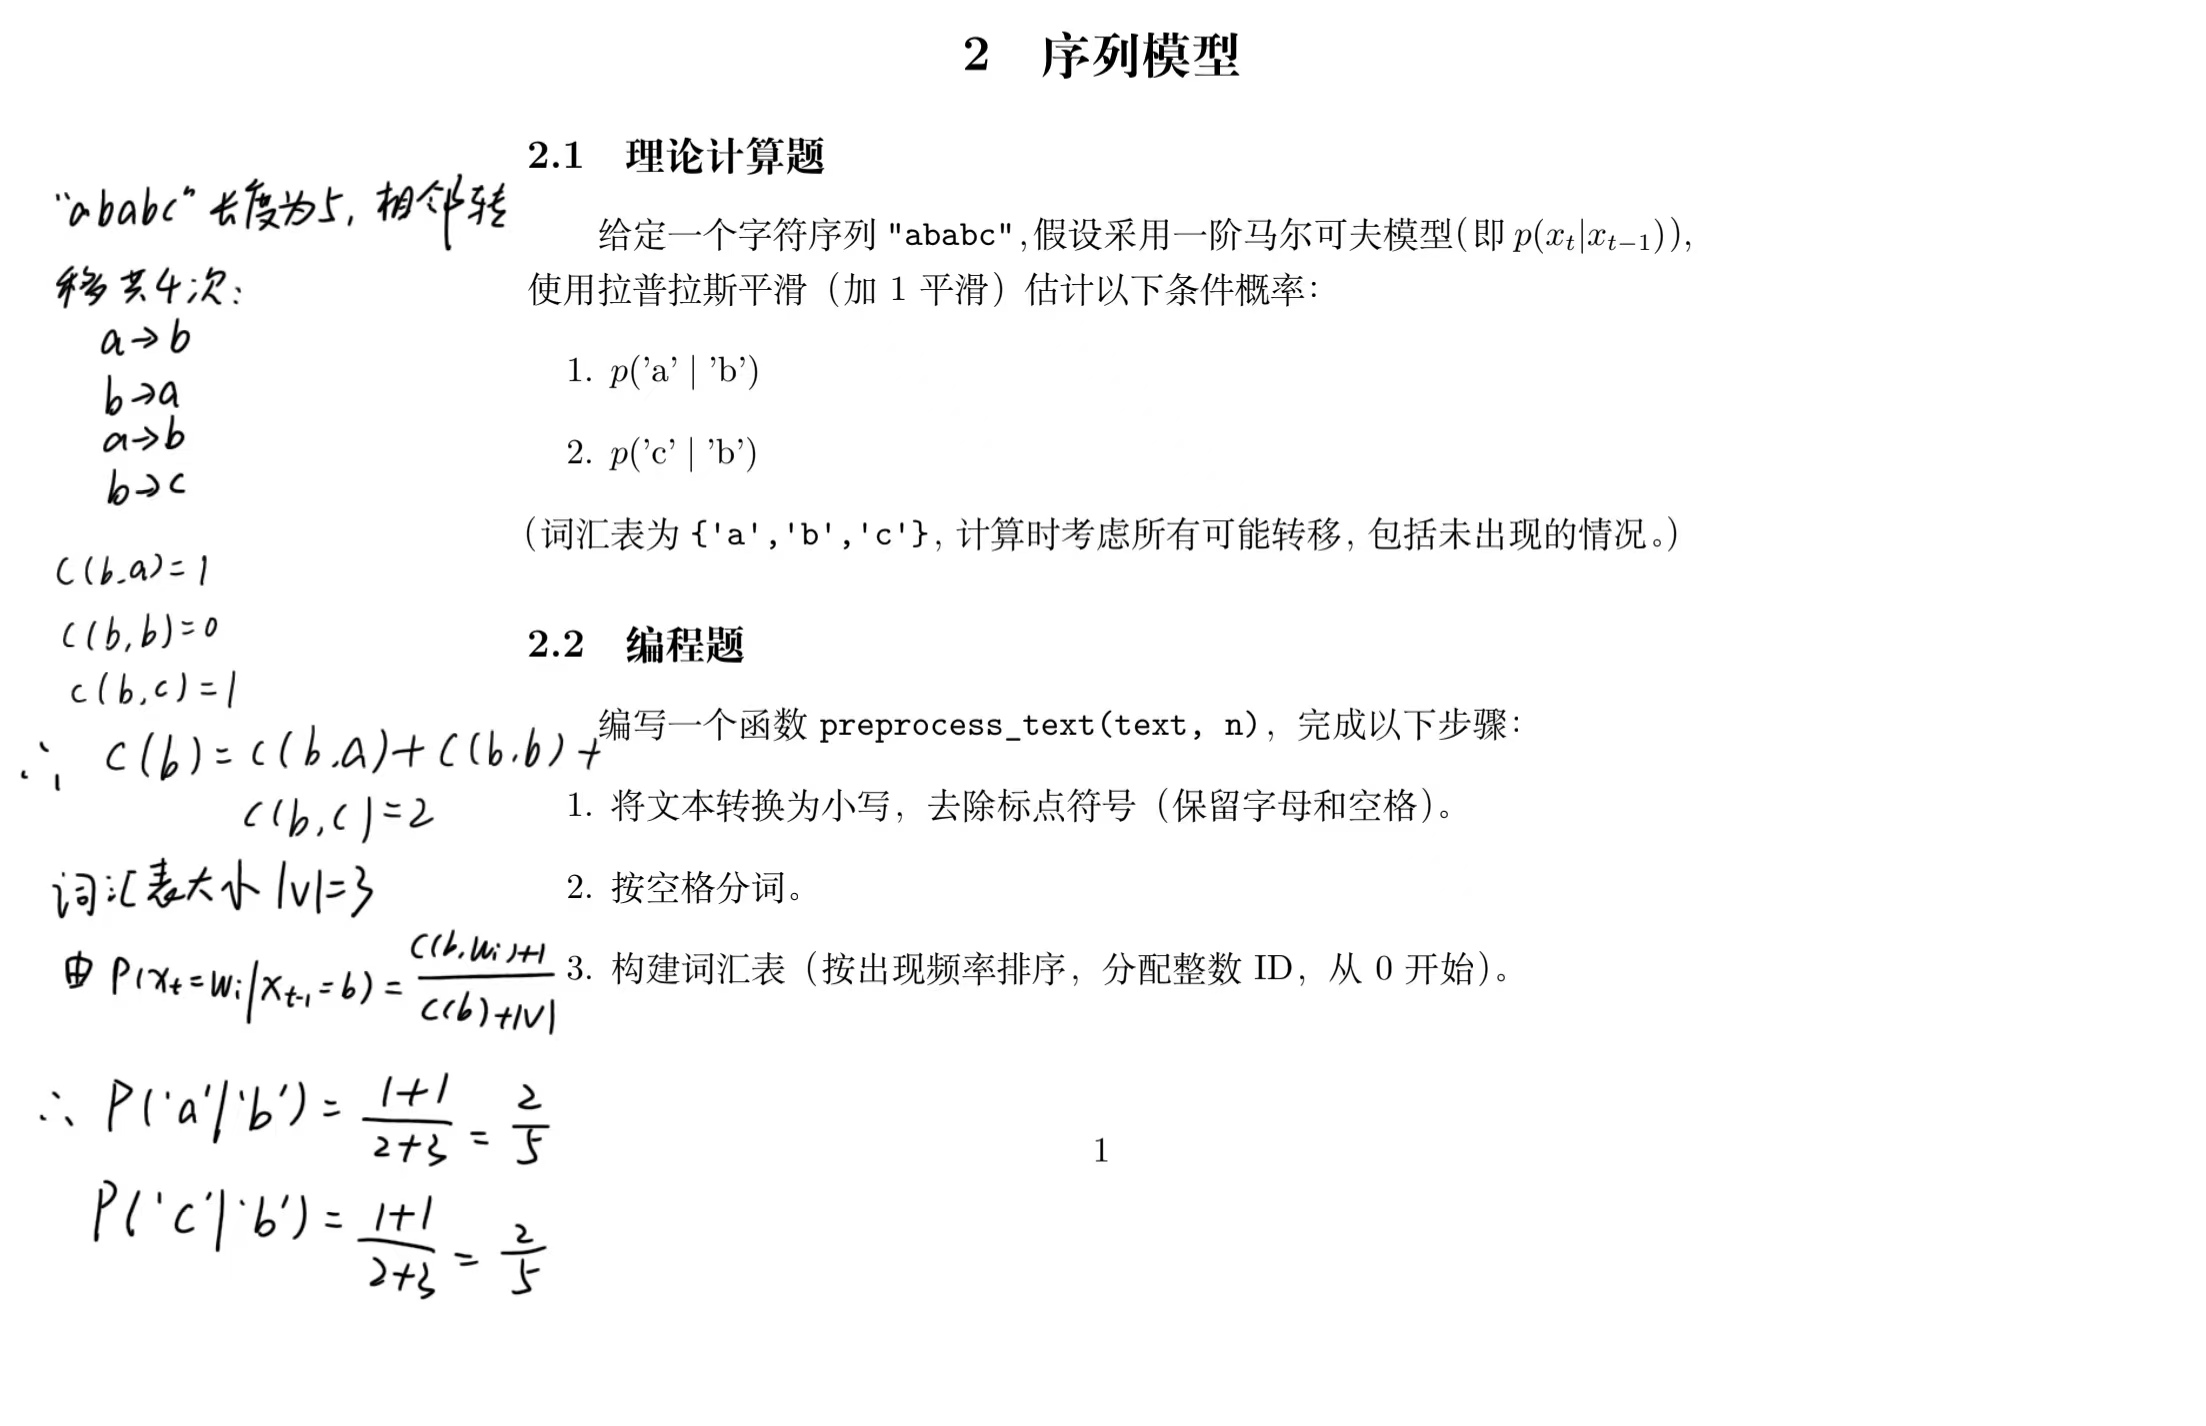

In [3]:
def preprocess_text(text, n):
    """
    1. 转小写，去除标点（保留字母和空格）
    2. 按空格分词
    3. 按词频构建词汇表（从0开始）
    4. 滑动窗口生成特征序列和标签（无后续词则忽略）
    返回：词汇表字典, (特征列表, 标签列表)
    """
    # 1. 只保留字母和空格，转小写
    text = re.sub(r'[^a-zA-Z\s]', '', text).lower()
    
    # 2. 分词
    tokens = text.split()
    
    # 3. 构建词汇表（按频率降序，相同频率按字母顺序）
    freq = Counter(tokens)
    sorted_vocab = sorted(freq.items(), key=lambda x: (-x[1], x[0]))
    word2id = {word: idx for idx, (word, _) in enumerate(sorted_vocab)}
    
    # 4. 滑动窗口生成特征和标签
    features = []
    labels = []
    # 窗口起始位置 i，特征为 tokens[i : i+n]
    for i in range(len(tokens) - n + 1):
        feat = tokens[i : i+n]
        # 若存在下一个词则作为标签，否则忽略该样本
        if i + n < len(tokens):
            features.append(feat)
            labels.append(tokens[i+n])
        # 否则不添加（忽略）
    
    return word2id, (features, labels)


# ---------- 测试 ----------
if __name__ == "__main__":
    vocab, (feats, lbls) = preprocess_text("The time machine", 2)
    print("词汇表:", vocab)
    print("特征:", feats)   
    print("标签:", lbls)    

词汇表: {'machine': 0, 'the': 1, 'time': 2}
特征: [['the', 'time']]
标签: ['machine']


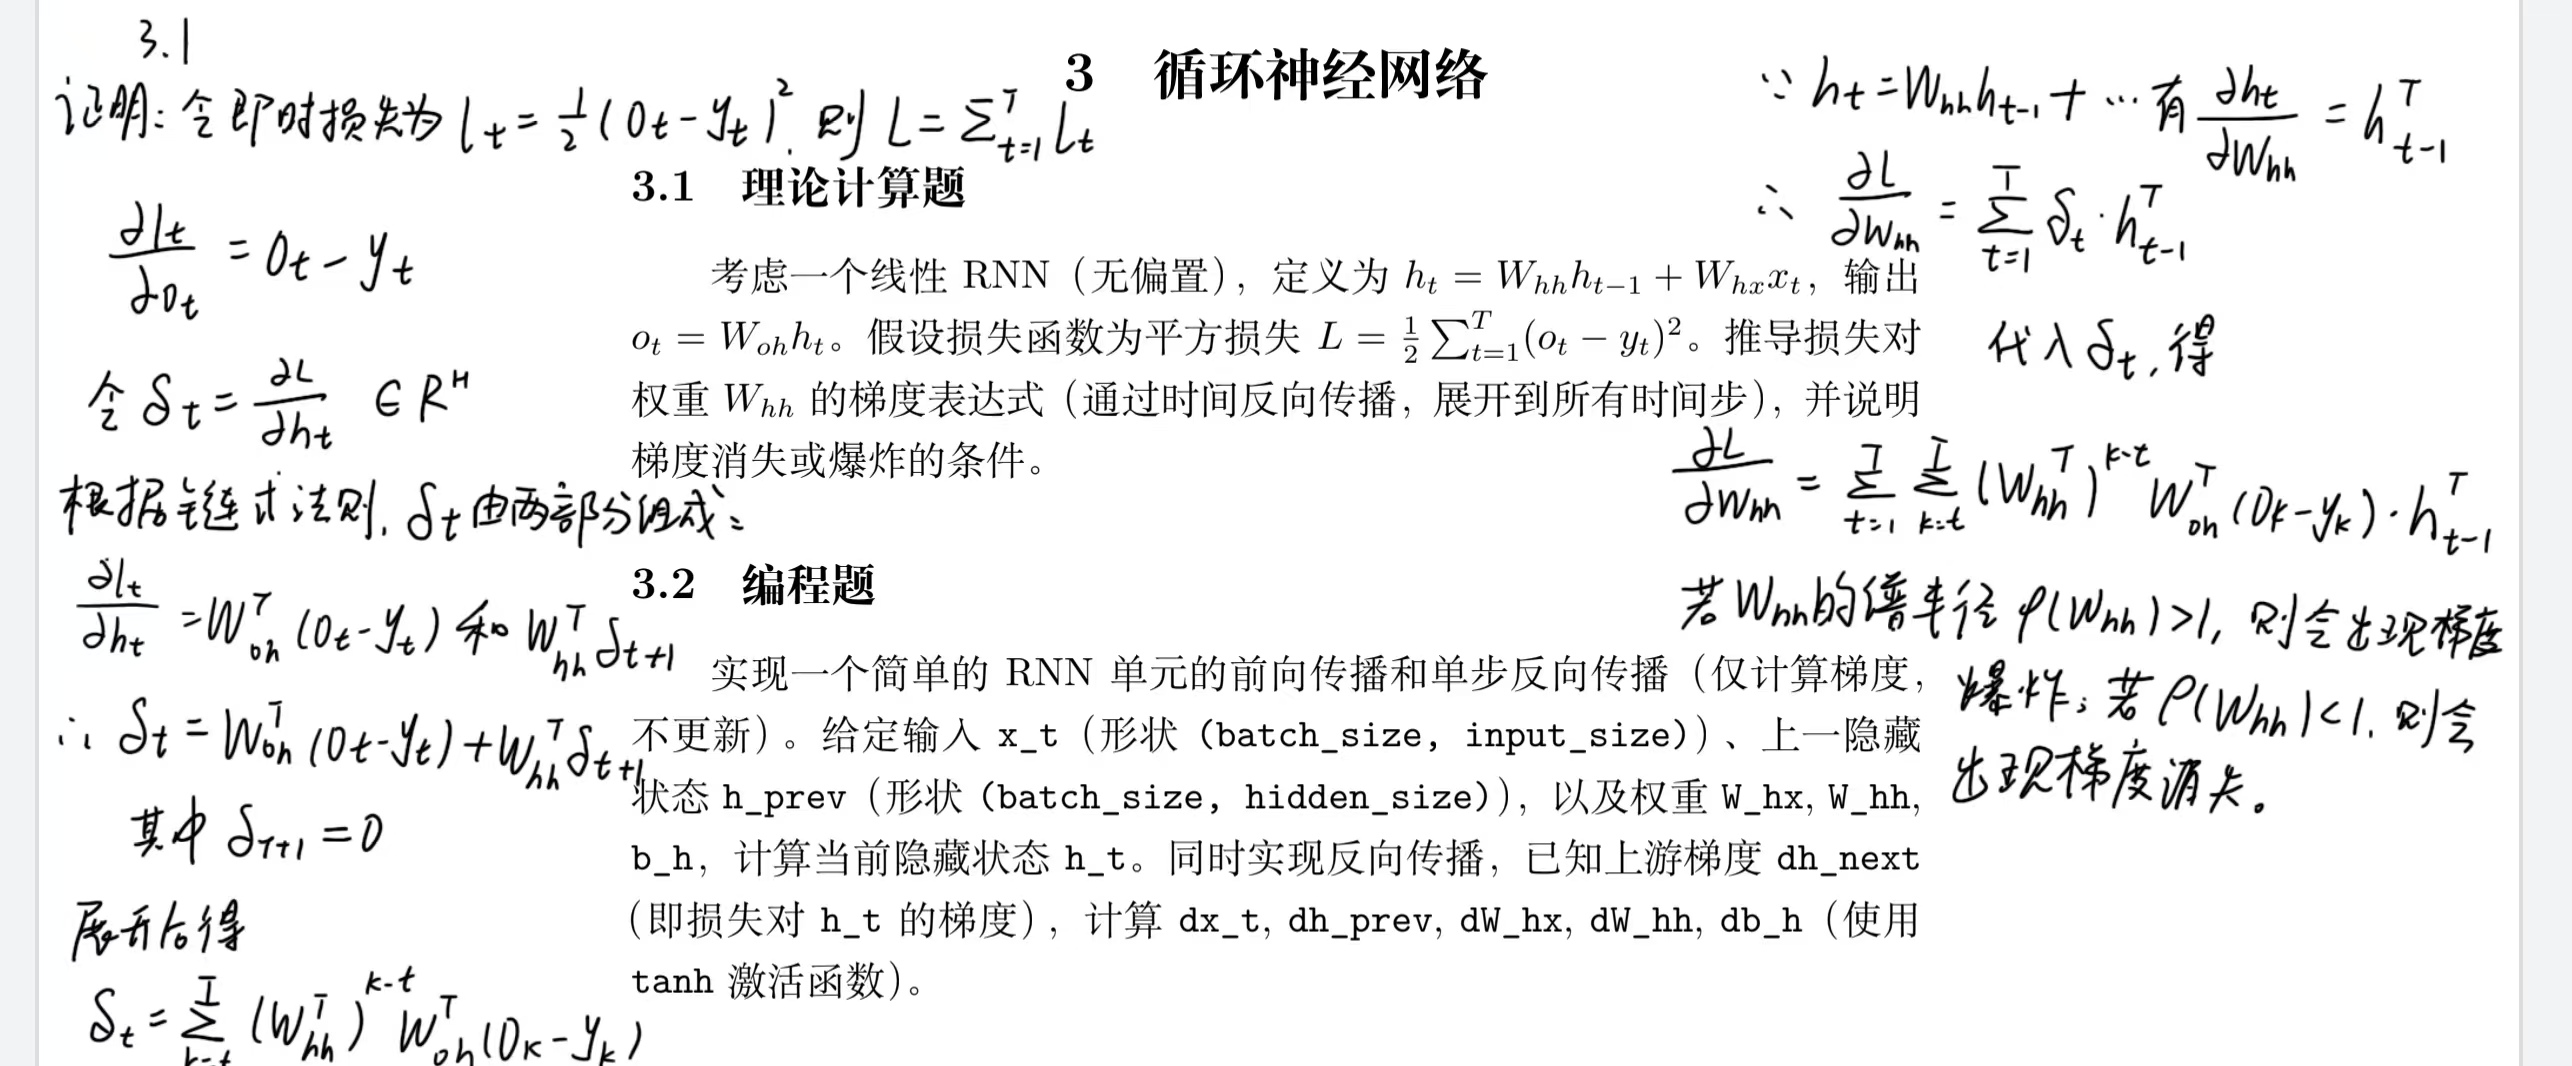

In [4]:
def rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h):
    """
    x_t:   (batch_size, input_size)
    h_prev:(batch_size, hidden_size)
    W_hx:  (input_size, hidden_size)
    W_hh:  (hidden_size, hidden_size)
    b_h:   (hidden_size,)
    返回: h_t (batch_size, hidden_size)
    """
    h_t = torch.tanh(x_t @ W_hx + h_prev @ W_hh + b_h)
    return h_t


def rnn_cell_backward(x_t, h_prev, h_t, dh_next, W_hx, W_hh):
    """
    dh_next: 上游梯度，即 dL/dh_t，形状 (batch_size, hidden_size)
    返回: dx_t, dh_prev, dW_hx, dW_hh, db_h
    """
    # tanh 的导数: dtanh = 1 - h_t^2
    d_act = dh_next * (1 - h_t ** 2)   # (batch_size, hidden_size)
    
    # 链式法则
    dx_t = d_act @ W_hx.T              # (batch_size, input_size)
    dh_prev = d_act @ W_hh.T           # (batch_size, hidden_size)
    dW_hx = x_t.T @ d_act              # (input_size, hidden_size)
    dW_hh = h_prev.T @ d_act           # (hidden_size, hidden_size)
    db_h = torch.sum(d_act, dim=0)     # (hidden_size,)
    
    return dx_t, dh_prev, dW_hx, dW_hh, db_h


# ---------- 测试 ----------
if __name__ == "__main__":
    torch.manual_seed(42)
    batch_size, input_size, hidden_size = 2, 3, 4
    x_t = torch.randn(batch_size, input_size)
    h_prev = torch.randn(batch_size, hidden_size)
    W_hx = torch.randn(input_size, hidden_size)
    W_hh = torch.randn(hidden_size, hidden_size)
    b_h = torch.randn(hidden_size)
    
    h_t = rnn_cell_forward(x_t, h_prev, W_hx, W_hh, b_h)
    dh_next = torch.randn_like(h_t)
    
    dx, dh_prev, dWx, dWh, db = rnn_cell_backward(x_t, h_prev, h_t, dh_next, W_hx, W_hh)
    
    print("前向 h_t 形状:", h_t.shape)
    print("反向 dx_t 形状:", dx.shape)
    print("反向 dh_prev 形状:", dh_prev.shape)
    print("反向 dW_hx 形状:", dWx.shape)
    print("反向 dW_hh 形状:", dWh.shape)
    print("反向 db_h 形状:", db.shape)

前向 h_t 形状: torch.Size([2, 4])
反向 dx_t 形状: torch.Size([2, 3])
反向 dh_prev 形状: torch.Size([2, 4])
反向 dW_hx 形状: torch.Size([3, 4])
反向 dW_hh 形状: torch.Size([4, 4])
反向 db_h 形状: torch.Size([4])


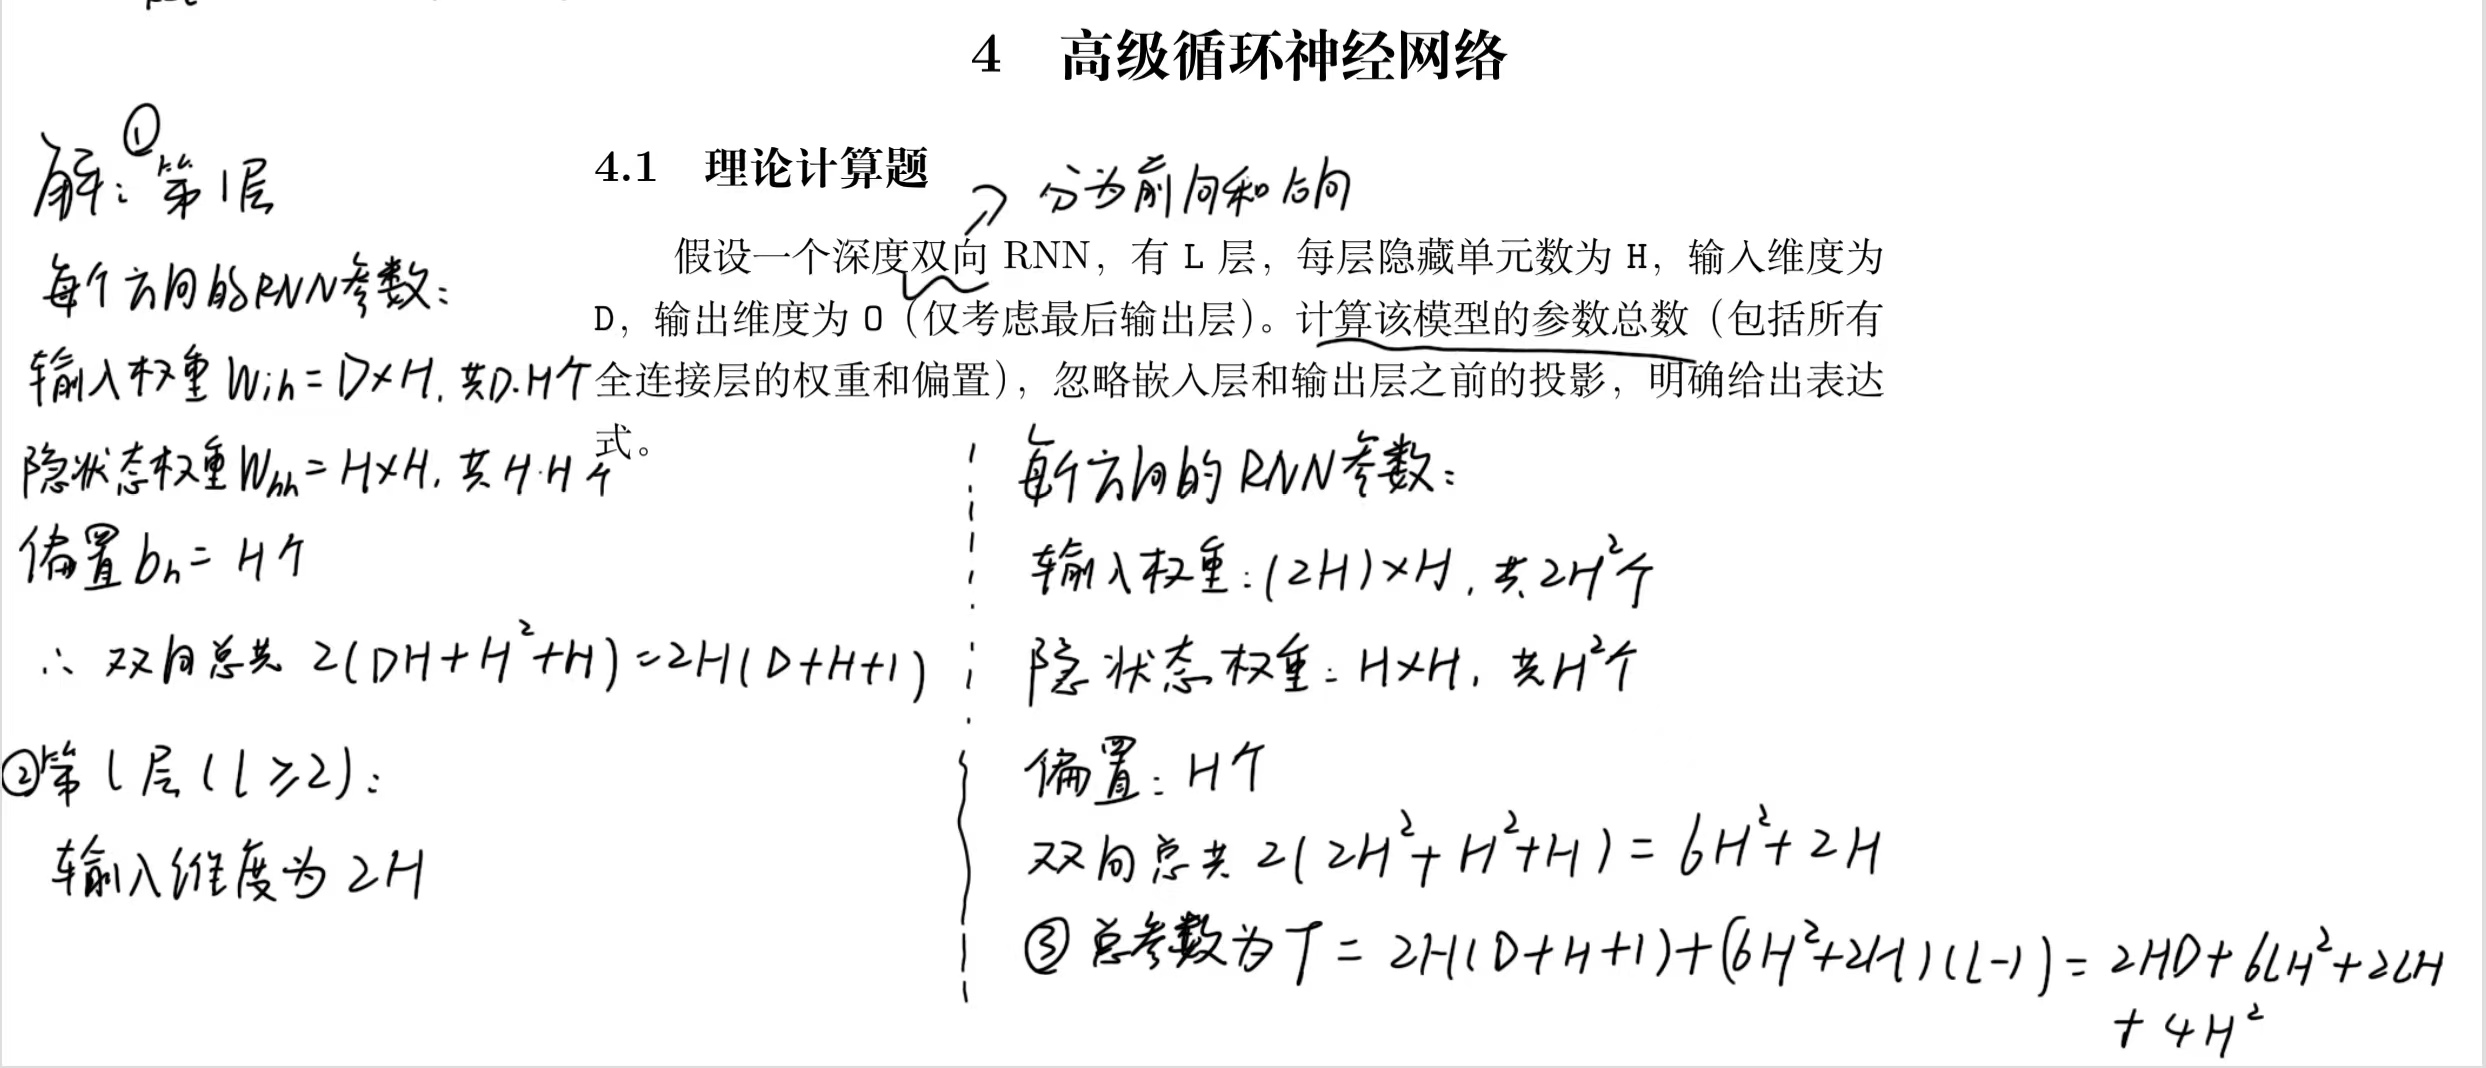

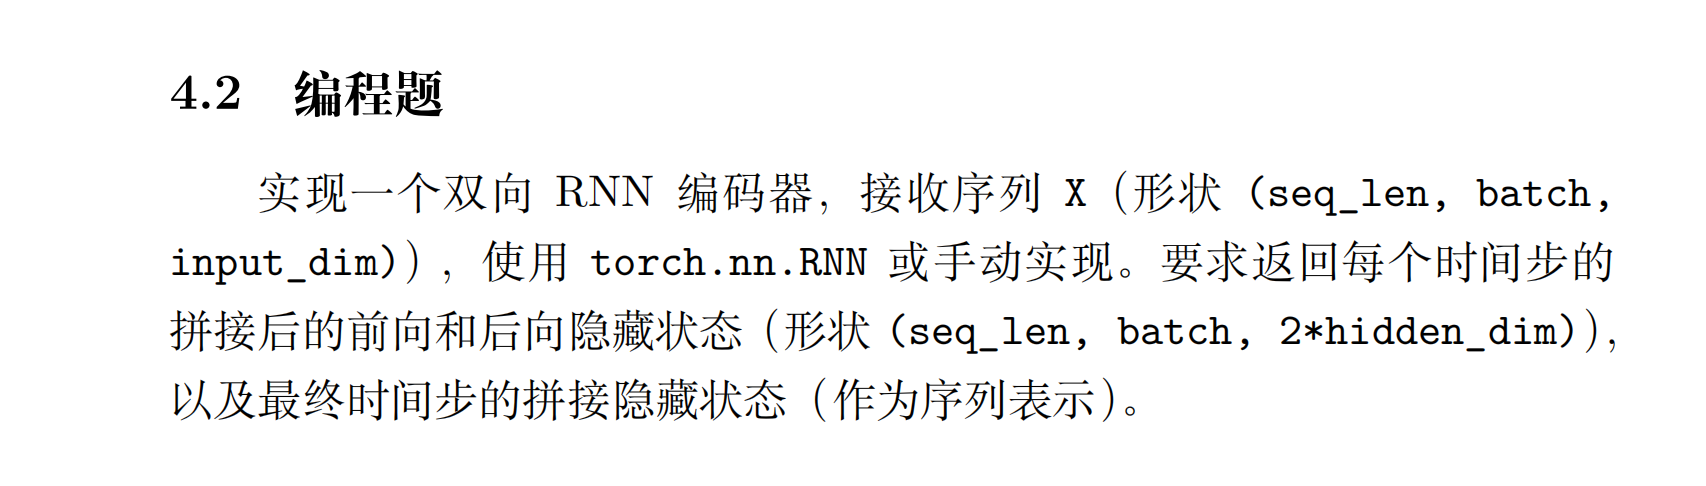

In [ ]:
def bidirectional_rnn_encoder(X, hidden_dim, num_layers=1):
    """
    X: (seq_len, batch, input_dim)
    返回:
      output: 每个时间步拼接的隐藏状态 (seq_len, batch, 2*hidden_dim)
      final_hidden: 最终时间步拼接隐藏状态 (batch, 2*hidden_dim)
    """
    input_dim = X.shape[2]
    
    # 双向 RNN，batch_first=False 保持输入格式
    rnn = torch.nn.RNN(
        input_size=input_dim,
        hidden_size=hidden_dim,
        num_layers=num_layers,
        bidirectional=True,
        batch_first=False
    )
    
    output, h_n = rnn(X)
    # output: (seq_len, batch, 2*hidden_dim)
    # h_n: (num_layers * 2, batch, hidden_dim)
    
    # 提取最后一层的前向和后向最终隐藏状态
    # 索引规律: 前向层索引 = 2*(layer-1), 后向层索引 = 2*(layer-1)+1
    forward_idx = 2 * (num_layers - 1)
    backward_idx = 2 * (num_layers - 1) + 1
    final_hidden = torch.cat([h_n[forward_idx], h_n[backward_idx]], dim=-1)  # (batch, 2*hidden_dim)
    
    return output, final_hidden


# ---------- 测试 ----------
if __name__ == "__main__":
    seq_len, batch, input_dim = 5, 3, 8
    hidden_dim = 4
    X = torch.randn(seq_len, batch, input_dim)
    
    out, final = bidirectional_rnn_encoder(X, hidden_dim, num_layers=1)
    print("输出形状 (seq_len, batch, 2*hidden):", out.shape)   
    print("最终拼接隐藏状态 (batch, 2*hidden):", final.shape) 

输出形状 (seq_len, batch, 2*hidden): torch.Size([5, 3, 8])
最终拼接隐藏状态 (batch, 2*hidden): torch.Size([3, 8])


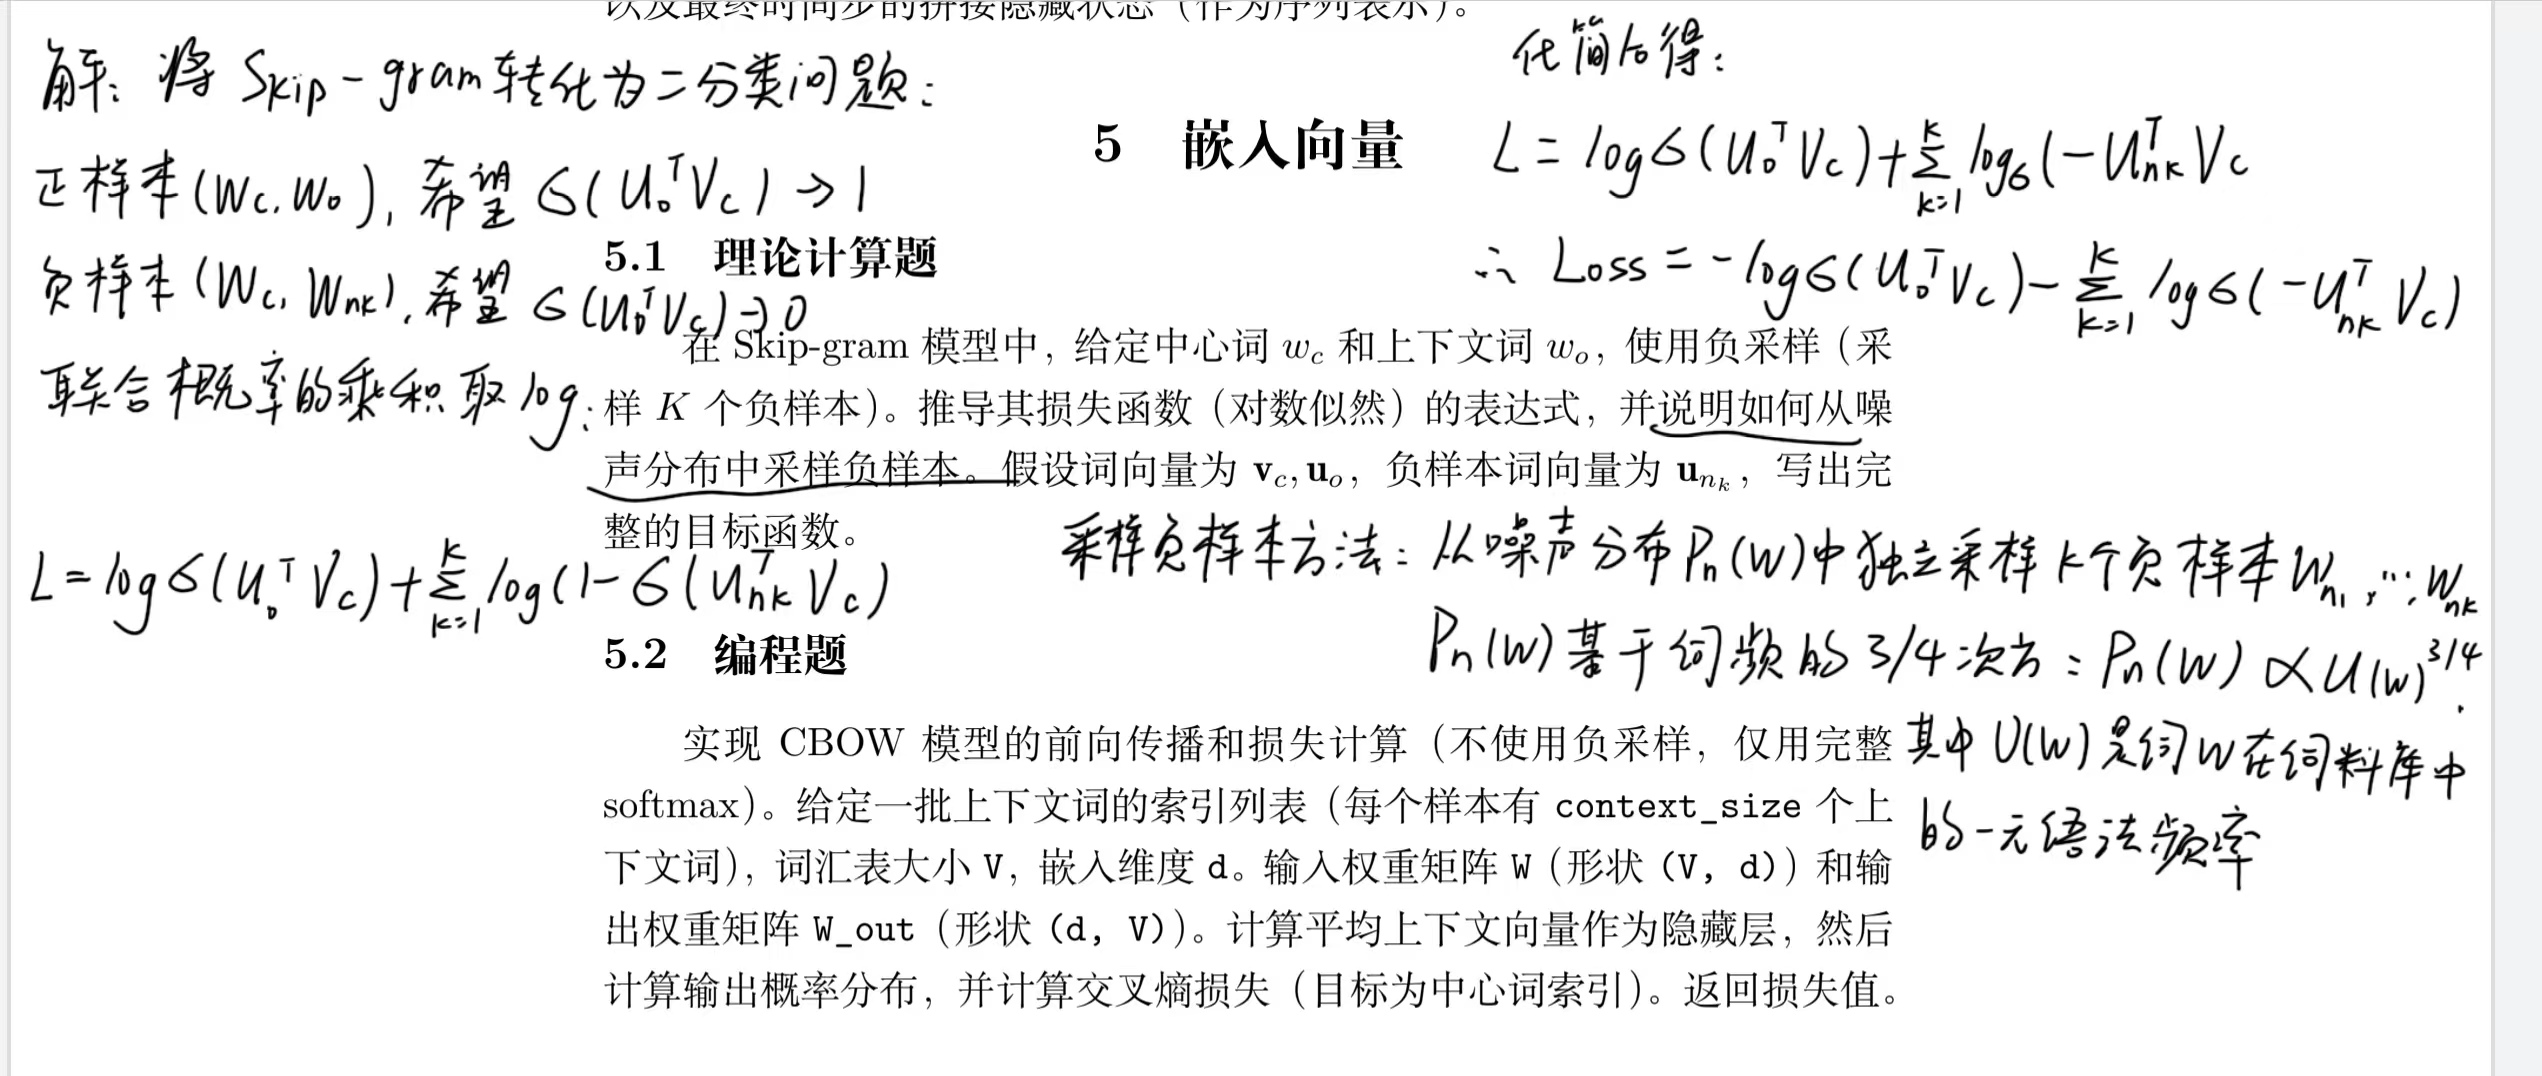

In [6]:
def cbow_forward(context_idxs, target_idxs, W, W_out):
    """
    context_idxs: (batch_size, context_size)  上下文词索引
    target_idxs:  (batch_size,)               中心词索引
    W:            (V, d)                      输入嵌入矩阵
    W_out:        (d, V)                      输出权重矩阵
    返回: 交叉熵损失 (标量张量)
    """
    batch_size, context_size = context_idxs.shape
    V, d = W.shape
    
    # 1. 取上下文词嵌入
    emb = W[context_idxs]                # (batch, context_size, d)
    
    # 2. 平均得到隐藏层向量
    h = emb.mean(dim=1)                  # (batch, d)
    
    # 3. 计算 logits（输出层得分）
    logits = h @ W_out                   # (batch, V)
    
    # 4. 交叉熵损失（内部包含 softmax）
    loss = F.cross_entropy(logits, target_idxs)
    
    return loss


# ---------- 测试 ----------
if __name__ == "__main__":
    torch.manual_seed(42)
    V, d = 10, 5
    batch_size, context_size = 4, 3
    
    W = torch.randn(V, d)
    W_out = torch.randn(d, V)
    context_idxs = torch.randint(0, V, (batch_size, context_size))
    target_idxs = torch.randint(0, V, (batch_size,))
    
    loss = cbow_forward(context_idxs, target_idxs, W, W_out)
    print("CBOW 损失值:", loss.item())

CBOW 损失值: 2.686213493347168


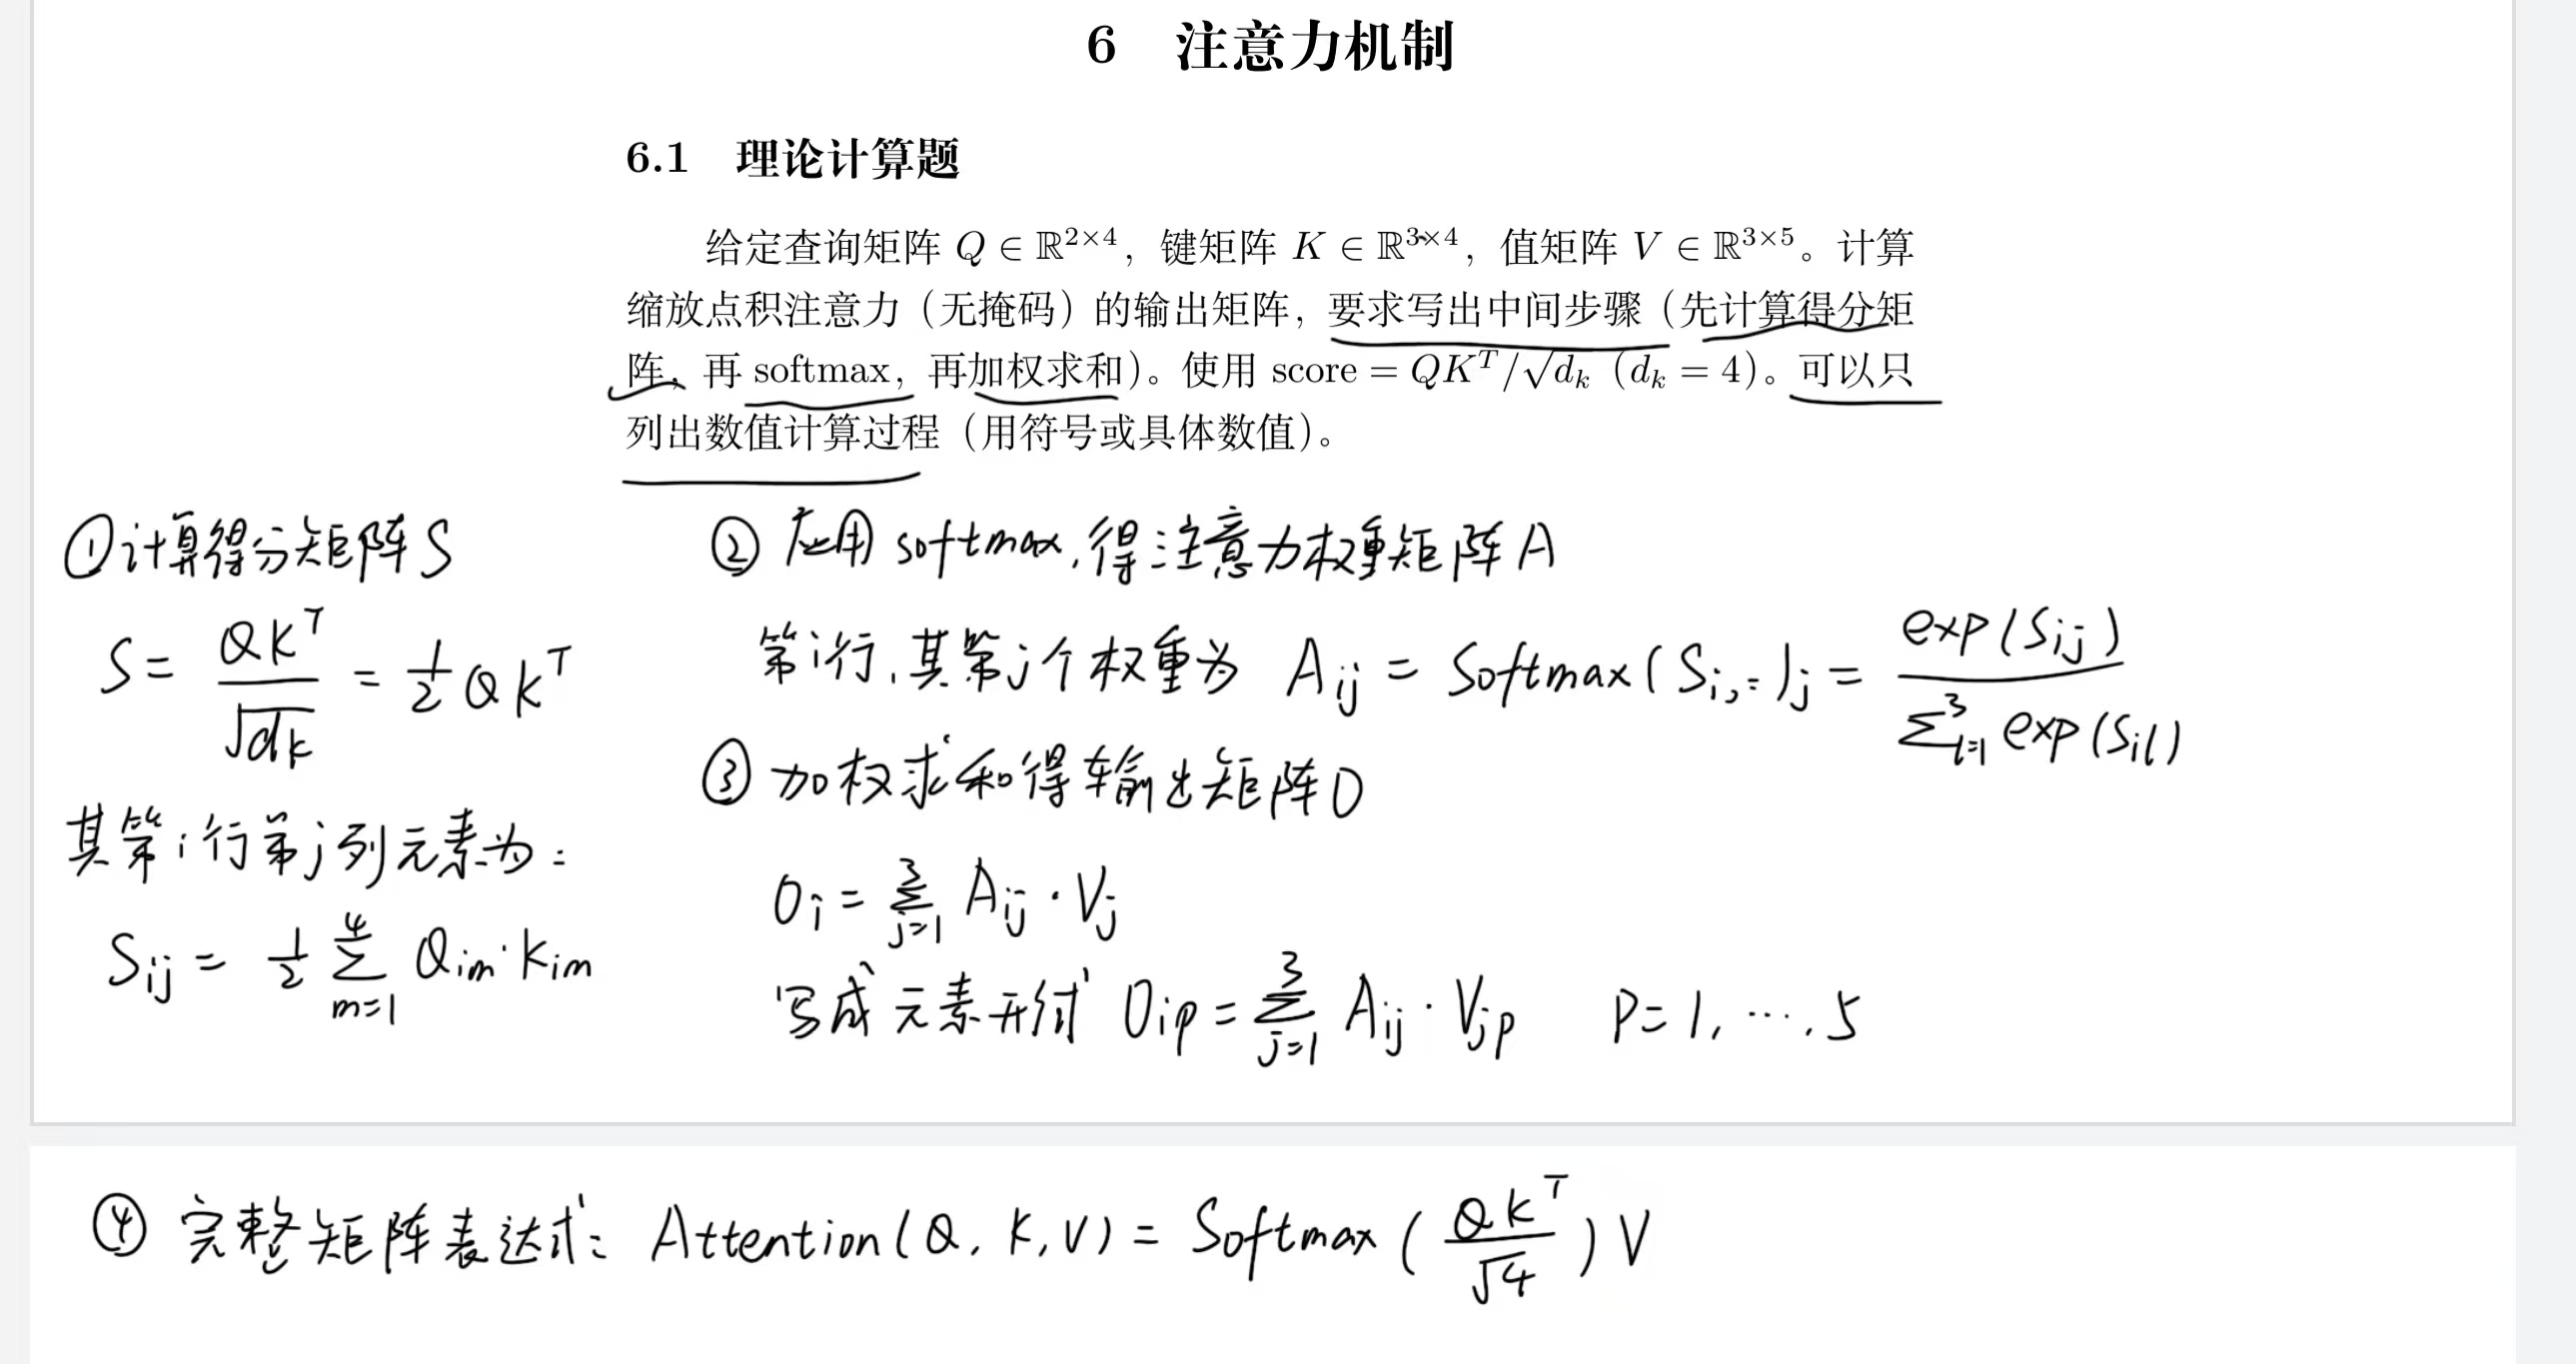

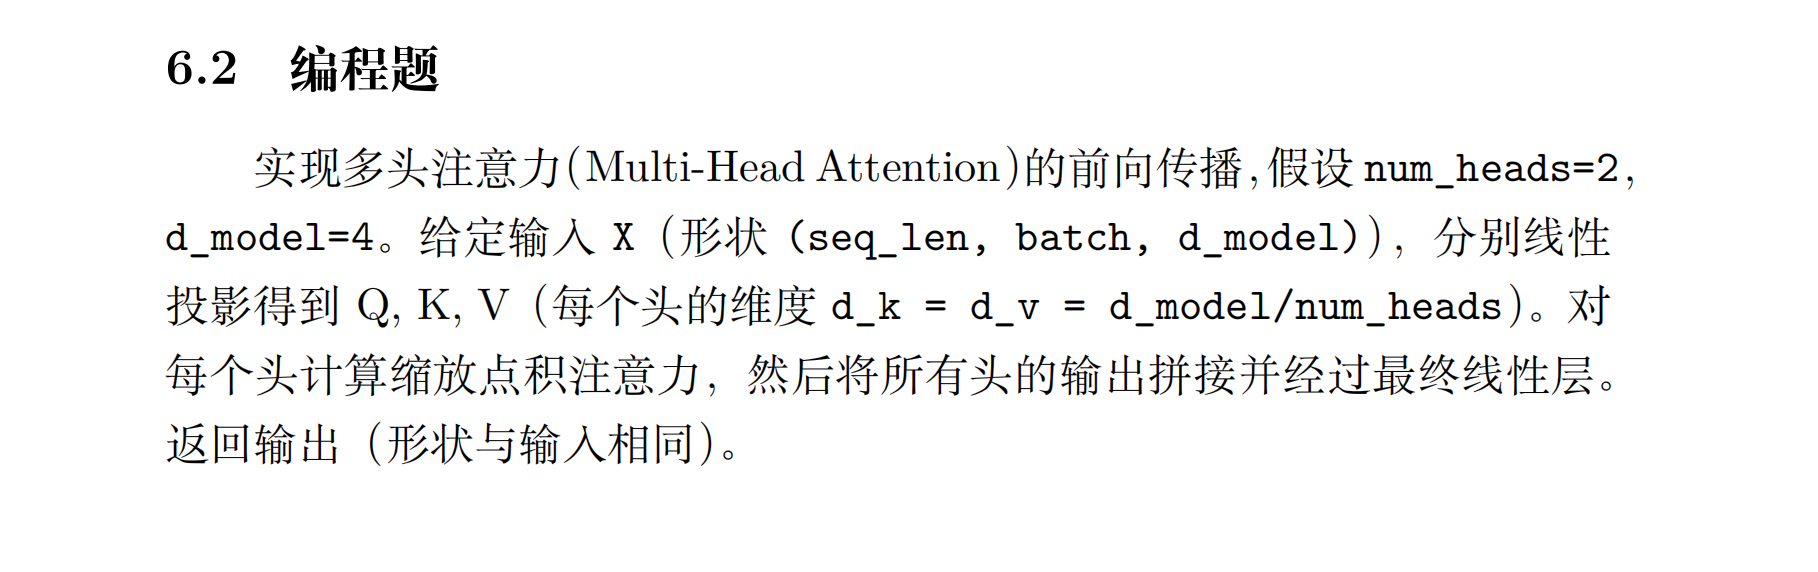

In [7]:
def multi_head_attention_forward(X, num_heads=2, d_model=4):
    """
    X: (seq_len, batch, d_model)
    假设 d_k = d_v = d_model // num_heads
    返回: 与 X 形状相同的输出 (seq_len, batch, d_model)
    """
    seq_len, batch, _ = X.shape
    d_k = d_v = d_model // num_heads
    
    # 初始化线性投影权重（实际应用中应作为可学习参数）
    torch.manual_seed(0)  # 固定随机权重以便复现
    W_q = torch.randn(d_model, d_model) * 0.01
    W_k = torch.randn(d_model, d_model) * 0.01
    W_v = torch.randn(d_model, d_model) * 0.01
    W_o = torch.randn(d_model, d_model) * 0.01
    
    # 1. 线性投影得到 Q, K, V
    Q = X @ W_q   # (seq_len, batch, d_model)
    K = X @ W_k
    V = X @ W_v
    
    # 2. 拆分为多头: (seq_len, batch, num_heads, d_k/d_v)
    Q = Q.view(seq_len, batch, num_heads, d_k)
    K = K.view(seq_len, batch, num_heads, d_k)
    V = V.view(seq_len, batch, num_heads, d_v)
    
    # 3. 调整维度便于批量矩阵乘法: (batch, num_heads, seq_len, d_k/d_v)
    Q = Q.permute(1, 2, 0, 3)
    K = K.permute(1, 2, 0, 3)
    V = V.permute(1, 2, 0, 3)
    
    # 4. 缩放点积注意力
    scores = (Q @ K.transpose(-2, -1)) / (d_k ** 0.5)  # (batch, heads, seq_len, seq_len)
    attn_weights = F.softmax(scores, dim=-1)
    out = attn_weights @ V                             # (batch, heads, seq_len, d_v)
    
    # 5. 合并多头: (seq_len, batch, d_model)
    out = out.permute(2, 0, 1, 3)                      # (seq_len, batch, heads, d_v)
    out = out.reshape(seq_len, batch, d_model)         # (seq_len, batch, d_model)
    
    # 6. 最终线性层
    output = out @ W_o                                 # (seq_len, batch, d_model)
    
    return output


# ---------- 测试 ----------
if __name__ == "__main__":
    seq_len, batch = 3, 2
    d_model = 4
    X = torch.randn(seq_len, batch, d_model)
    
    out = multi_head_attention_forward(X, num_heads=2, d_model=4)
    print("输入形状:", X.shape)   # (3, 2, 4)
    print("输出形状:", out.shape) # (3, 2, 4)

输入形状: torch.Size([3, 2, 4])
输出形状: torch.Size([3, 2, 4])
